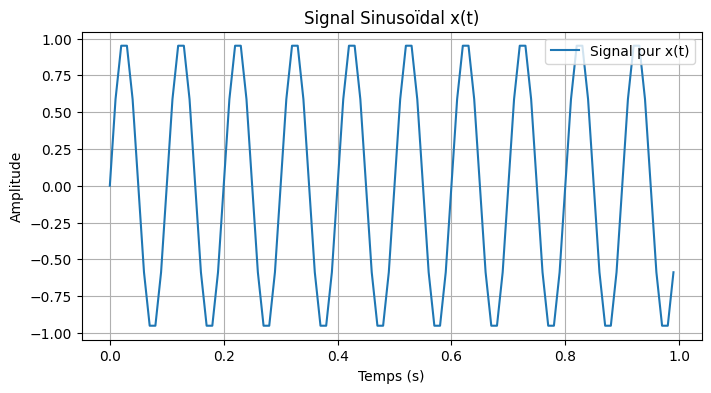

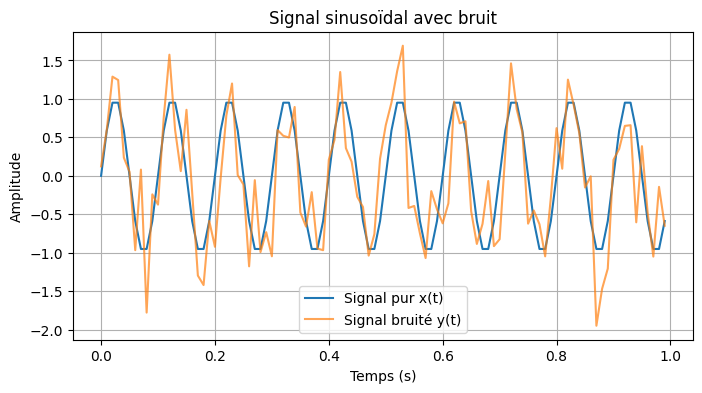

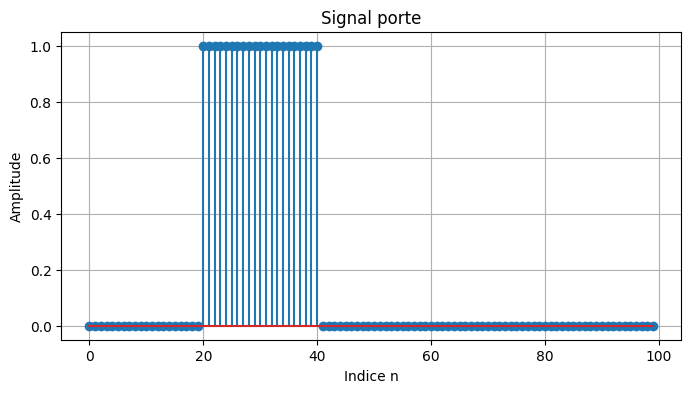

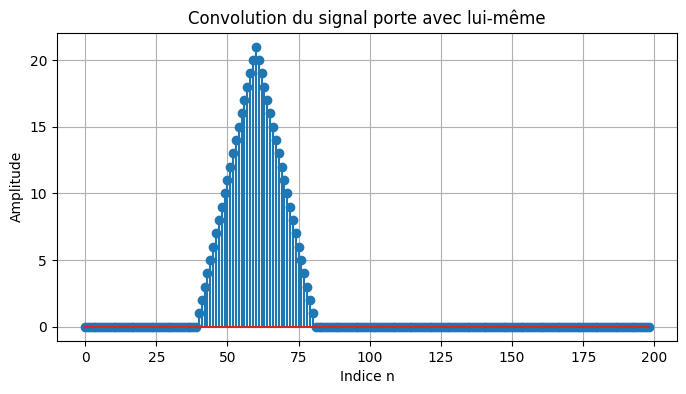

In [ ]:

# ================================
# -------------TP1----------------
# ================================

import numpy as np
import matplotlib.pyplot as plt

# Paramètres
A = 1
f0 = 10  
phi = 0  
fs = 100  
T = 1    

# Vecteur temps
t = np.arange(0, T, 1/fs)

# Signal sinusoïdal
x = A * np.sin(2 * np.pi * f0 * t + phi)

# Tracé
plt.figure(figsize=(8,4))
plt.plot(t, x, label='Signal pur x(t)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal Sinusoïdal x(t)')
plt.grid(True)
plt.legend()
plt.show()

# Générer un bruit blanc gaussien
bruit = np.random.normal(0, 0.5, size=x.shape)  # moyenne 0, écart-type 0.5

# Signal bruité
y = x + bruit

# Tracé du signal pur et bruité
plt.figure(figsize=(8,4))
plt.plot(t, x, label='Signal pur x(t)')
plt.plot(t, y, label='Signal bruité y(t)', alpha=0.7)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal sinusoïdal avec bruit')
plt.grid(True)
plt.legend()
plt.show()


N = 100
porte = np.zeros(N)
porte[20:41] = 1  

plt.figure(figsize=(8,4))
plt.stem(porte)  # enlever use_line_collection=True
plt.xlabel('Indice n')
plt.ylabel('Amplitude')
plt.title('Signal porte')
plt.grid(True)
plt.show()


conv_porte = np.convolve(porte, porte)

plt.figure(figsize=(8,4))
plt.stem(conv_porte)  # enlever use_line_collection=True
plt.xlabel('Indice n')
plt.ylabel('Amplitude')
plt.title('Convolution du signal porte avec lui-même')
plt.grid(True)
plt.show()






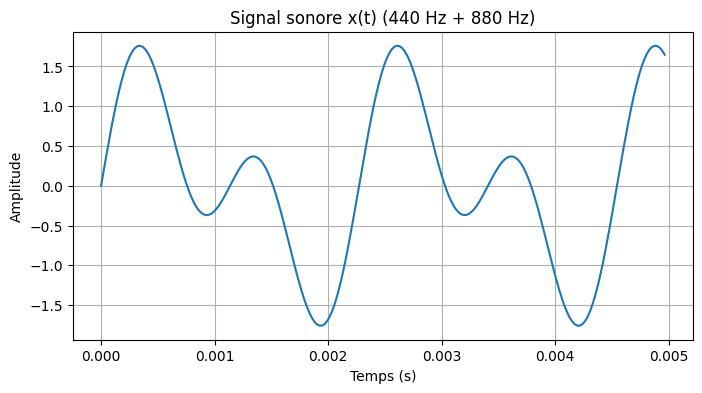

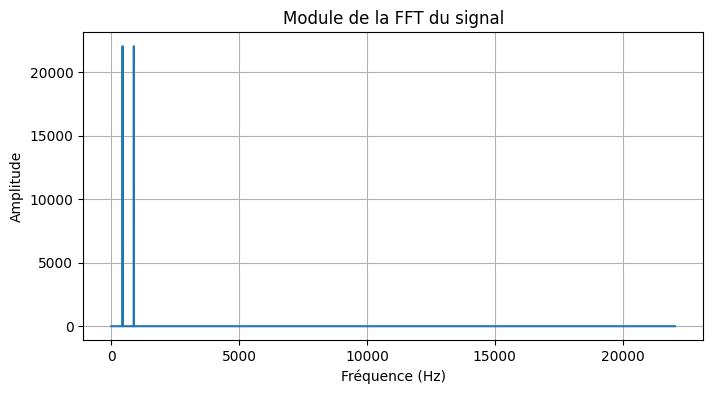

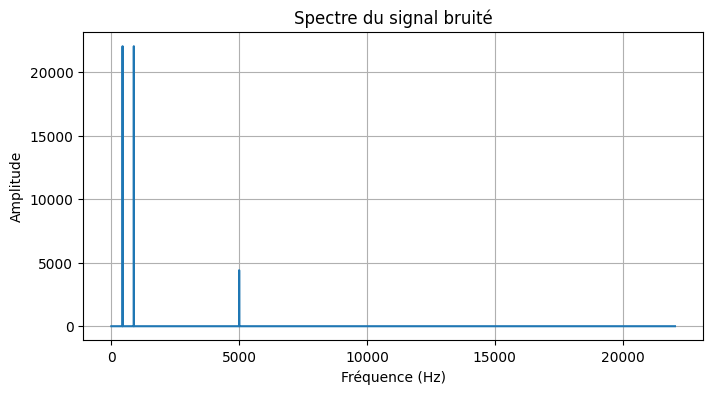

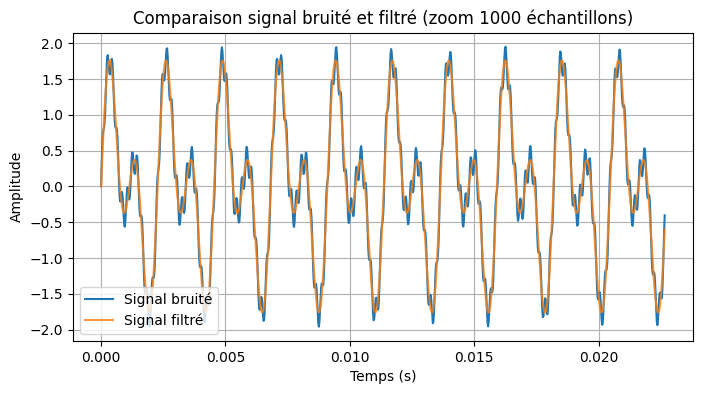

In [ ]:
# ================================
# -------------TP2----------------
# ================================

import numpy as np
import matplotlib.pyplot as plt

# Paramètres
fs = 44100        
T = 1            
f1 = 440          
f2 = 880          

t = np.arange(0, T, 1/fs)  

# Signal sonore composé de deux fréquences
signal = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)

# Tracé du signal temporel (zoom sur 5 ms pour voir les oscillations)
plt.figure(figsize=(8,4))
plt.plot(t[:220], signal[:220])  # 220 échantillons ~ 5 ms
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal sonore x(t) (440 Hz + 880 Hz)')
plt.grid(True)
plt.show()


# FFT du signal
N = len(signal)
Signal_fft = np.fft.fft(signal)
freq = np.fft.fftfreq(N, 1/fs)  

# Module de la FFT (on ne garde que la moitié positive)
plt.figure(figsize=(8,4))
plt.plot(freq[:N//2], np.abs(Signal_fft[:N//2]))
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.title('Module de la FFT du signal')
plt.grid(True)
plt.show()


fbruit = 5000
amplitude_bruit = 0.2

signal_bruite = signal + amplitude_bruit*np.sin(2*np.pi*fbruit*t)

# Tracé du spectre du signal bruité
Signal_bruite_fft = np.fft.fft(signal_bruite)

plt.figure(figsize=(8,4))
plt.plot(freq[:N//2], np.abs(Signal_bruite_fft[:N//2]))
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectre du signal bruité')
plt.grid(True)
plt.show()


Signal_fft_filtre = Signal_bruite_fft.copy()

# Filtre passe-bas : supprimer les fréquences > 2000 Hz
Signal_fft_filtre[np.abs(freq) > 2000] = 0

# Transformée de Fourier inverse
signal_filtre = np.fft.ifft(Signal_fft_filtre)

# Tracé comparatif
plt.figure(figsize=(8,4))
plt.plot(t[:1000], signal_bruite[:1000], label='Signal bruité')
plt.plot(t[:1000], signal_filtre[:1000].real, label='Signal filtré', alpha=0.8)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Comparaison signal bruité et filtré (zoom 1000 échantillons)')
plt.legend()
plt.grid(True)
plt.show()

Choisissez votre fichier WAV (44.1 kHz)


Saving WhatsApp Audio 2026-02-24 at 01.00.34.mp4 to WhatsApp Audio 2026-02-24 at 01.00.34.mp4
Fréquence d'échantillonnage originale : 44100 Hz
Lecture du signal original :


/tmp/ipython-input-1066244452.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, fs = librosa.load(filename, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Nouvelle fréquence après sous-échantillonnage : 4410 Hz
Lecture du signal sous-échantillonné :


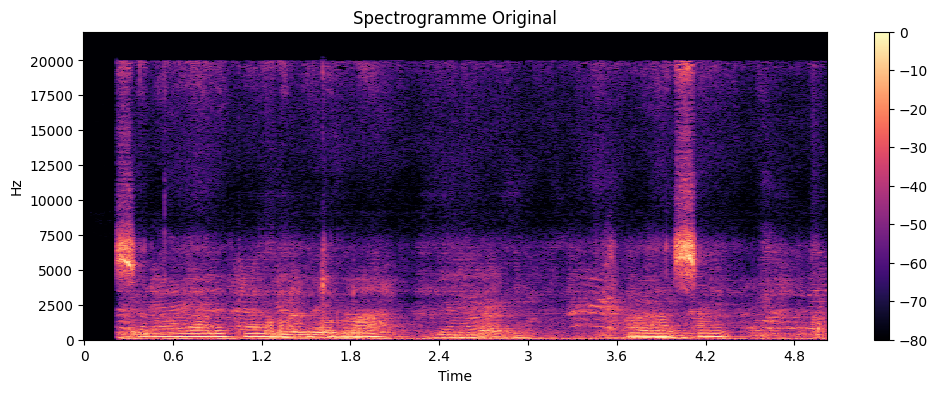

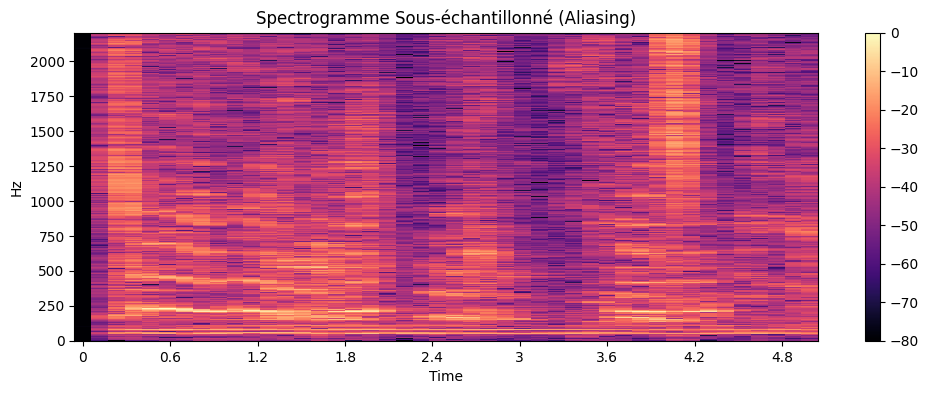

Choisissez une image


Saving p1100251.jpg to p1100251 (2).jpg


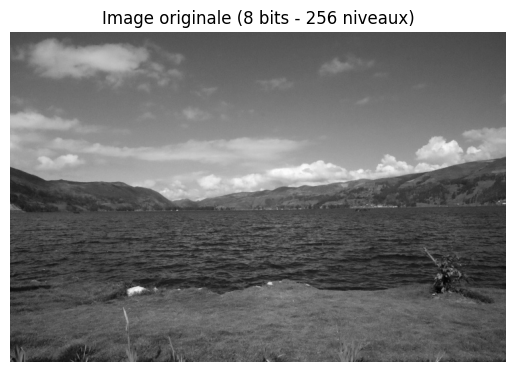

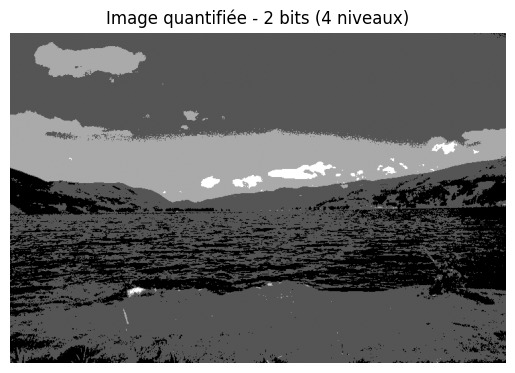

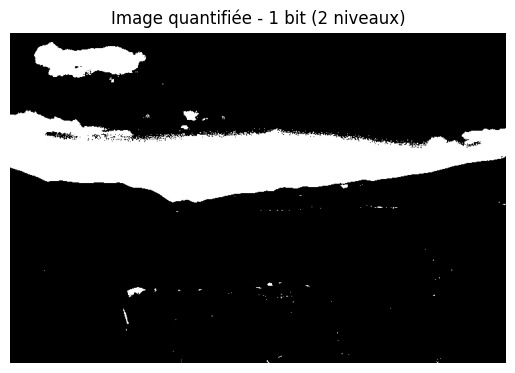

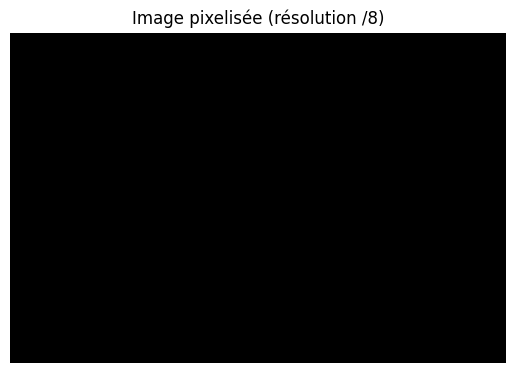

In [ ]:
# ================================
# TP3 - Partie 1 : Aliasing
# ================================

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from IPython.display import Audio


# 1) Charger un fichier audio (upload)

print("Choisissez votre fichier WAV (44.1 kHz)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

signal, fs = librosa.load(filename, sr=None)
print("Fréquence d'échantillonnage originale :", fs, "Hz")

# Écouter le signal original
print("Lecture du signal original :")
display(Audio(signal, rate=fs))



# 2) Sous-échantillonnage sauvage (1 sur 10)

signal_sous = signal[::10]
fs_sous = fs // 10

print("Nouvelle fréquence après sous-échantillonnage :", fs_sous, "Hz")

# Écouter le signal sous-échantillonné
print("Lecture du signal sous-échantillonné :")
display(Audio(signal_sous, rate=fs_sous))


# 3) Sauvegarder le résultat

sf.write("audio_sous_echantillonne.wav", signal_sous, fs_sous)



# 4) Comparaison des spectrogrammes

plt.figure(figsize=(12,4))
D_original = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
librosa.display.specshow(D_original, sr=fs, x_axis='time', y_axis='hz')
plt.title("Spectrogramme Original")
plt.colorbar()
plt.show()

plt.figure(figsize=(12,4))
D_sous = librosa.amplitude_to_db(np.abs(librosa.stft(signal_sous)), ref=np.max)
librosa.display.specshow(D_sous, sr=fs_sous, x_axis='time', y_axis='hz')
plt.title("Spectrogramme Sous-échantillonné (Aliasing)")
plt.colorbar()
plt.show()


















# =========================================
# TP3 - Partie 2 : Image et Quantification
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from google.colab import files
from PIL import Image
from io import BytesIO


# 1) Charger une image en niveaux de gris (8 bits)


print("Choisissez une image")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image = Image.open(BytesIO(uploaded[filename])).convert('L')  # conversion en gris (8 bits)
image = np.array(image)

plt.figure()
plt.imshow(image, cmap='gray')
plt.title("Image originale (8 bits - 256 niveaux)")
plt.axis('off')
plt.show()



# 2) Réduction des niveaux de gris


# 2 bits -> 4 niveaux
image_2bits = (image // 64) * 64

# 1 bit -> 2 niveaux
image_1bit = (image // 128) * 255

plt.figure()
plt.imshow(image_2bits, cmap='gray')
plt.title("Image quantifiée - 2 bits (4 niveaux)")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(image_1bit, cmap='gray')
plt.title("Image quantifiée - 1 bit (2 niveaux)")
plt.axis('off')
plt.show()



# 4) Pixelisation (réduction résolution spatiale)


h, w = image.shape

# réduire taille /8
image_small = transform.resize(image, (h//8, w//8), anti_aliasing=True)

# ré-agrandir à taille originale
image_pixel = transform.resize(image_small, (h, w), order=0, preserve_range=True)

plt.figure()
plt.imshow(image_pixel.astype(np.uint8), cmap='gray')
plt.title("Image pixelisée (résolution /8)")
plt.axis('off')
plt.show()